In [1]:
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from tqdm.auto import tqdm
from genkit import AlphaStableFlowLinear, DLPMEps, DLPMEpsOrigin, GaussianFlowDDPM, GaussianFlowLinear, GaussianFlowOT, ScoreSDEOrigin, FlowMatchingOrigin
from genkit.diffusion import DDPMV, DDPMX0
from genkit.datasets import fetch_real_data, fetch_synthetic_data
from genkit.inspect import model_est_jacobian_spectral_curve
from genkit.metrics import metric_on_quantile, mmd_rbf, mssle, wasserstein_distance
from genkit.nn import MLPModel
from genkit.plotting import PRETTY_RCPARAMS
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor
from genkit.utils import format_duration

repo_root = Path.cwd().resolve()
if not (repo_root / "benchmarks" / "_utils.py").exists() and (repo_root.parent / "benchmarks" / "_utils.py").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from benchmarks.runner.utils import summarize_metric_values, format_mean_std_latex

plt.rcParams.update(PRETTY_RCPARAMS)


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_specs = [
    {
        "name": "DDPM-V",
        "cls": DDPMV,
        "source_distri": "Gaussian",
        "extra_kwargs": {},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:green",
        "linestyle": "solid",
        "marker": "o",
    },
    # {
    #     "name": "DDPM-X0",
    #     "cls": DDPMX0,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:olive",
    #     "linestyle": "solid",
    #     "marker": "s",
    # },
    {
        "name": "GF-Linear",
        "cls": GaussianFlowLinear,
        "source_distri": "Gaussian",
        "extra_kwargs": {},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:blue",
        "linestyle": "dashdot",
        "marker": "^",
    },
    # {
    #     "name": "GF-Linear-Orig",
    #     "cls": FlowMatchingOrigin,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:cyan",
    #     "linestyle": "dashdot",
    #     "marker": "^",
    # },
    # {
    #     "name": "GF-OT",
    #     "cls": GaussianFlowOT,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:purple",
    #     "linestyle": "dashdot",
    #     "marker": "P",
    # },
    # {
    #     "name": "GF-DDPM",
    #     "cls": GaussianFlowDDPM,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:red",
    #     "linestyle": "dashdot",
    #     "marker": "X",
    # },
    {
        "name": "ASF-Linear",
        "cls": AlphaStableFlowLinear,
        "source_distri": "AlphaStable",
        "extra_kwargs": {"alpha": 1.6},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:brown",
        "linestyle": "dotted",
        "marker": "v",
    },
    {
        "name": "DLPM",
        "cls": DLPMEps,
        "source_distri": "AlphaStable",
        "extra_kwargs": {"alpha": 1.6},
        "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
        "color": "tab:orange",
        "linestyle": "dashed",
        "marker": "D",
    },
    # {
    #     "name": "DLPM-Orig",
    #     "cls": DLPMEpsOrigin,
    #     "source_distri": "AlphaStable",
    #     "extra_kwargs": {"alpha": 1.6},
    #     "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:pink",
    #     "linestyle": "dashed",
    #     "marker": "h",
    # },
    # {
    #     "name": "ScoreSDE-Orig",
    #     "cls": ScoreSDEOrigin,
    #     "source_distri": "Gaussian",
    #     "extra_kwargs": {},
    #     "train_kwargs": {"lr": 5e-3, "batch_size": 1024, "grad_clip_norm": 10.0},
    #     "color": "tab:cyan",
    #     "linestyle": "solid",
    #     "marker": "*",
    # },
]

In [ ]:
depth = 5
width = 64
time_dim = 32

n_steps = 128
n_epochs = 256
n_trials = 2
use_adamw = False
num_workers = 0

device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

source_order = [spec["name"] for spec in model_specs]
source_colors = {spec["name"]: spec["color"] for spec in model_specs}
net_kwargs = {"width": width, "depth": depth, "time_dim": time_dim}
base_train_kwargs = {
    "n_epochs": n_epochs,
    "use_adamw": use_adamw,
    "num_workers": num_workers,
    "device": device,
}

total_runs = len(model_specs) * n_trials


In [4]:
runs = []
trial_refs = {}

run_idx = 0
for trial_idx in range(n_trials):

    x_train, x_val, x_ref = fetch_synthetic_data("alpha_stable", alpha=1.6, n_samples=100_000, val_size=0.1, test_size=0.1, dim=2, device=device, dtype=fdtype)

    n_samples, dim = x_train.shape

    trial_refs[trial_idx] = x_ref[: min(n_samples, x_ref.shape[0])].clone()

    for spec in model_specs:
        run_idx += 1
        core_visitor = CoreMetricsVisitor()
        net = MLPModel(dim=dim, **net_kwargs).to(device=device, dtype=fdtype)
        generator = spec["cls"](
            net=net,
            dim=dim,
            n_steps=n_steps,
            device=device,
            fdtype=fdtype,
            idtype=idtype,
            **spec["extra_kwargs"],
        )
        run_train_kwargs = {**base_train_kwargs, **spec.get("train_kwargs", {})}

        t0 = time.perf_counter()
        msg = (
            f"[{run_idx:02d}/{total_runs:02d}] trial {trial_idx + 1}/{n_trials} {spec['name']}: "
            f"Training (nb train samples: {n_samples}, nb test samples: {len(x_ref)}, nb val samples: {len(x_val)},"
            f" dim: {dim}, max: {x_train.max():.1f}, min: {x_train.min():.1f}, lr: {run_train_kwargs['lr']:.1e}, "
            f"batch: {run_train_kwargs['batch_size']}, clip: {run_train_kwargs['grad_clip_norm']})..."
        )
        print(msg, end="")
        generator, diagnostics = train(
            generative_model=generator,
            target_data=x_train.clone(),
            visitors=[core_visitor],
            **run_train_kwargs,
        )
        print(f"Done (in {format_duration(time.perf_counter() - t0)} s).")

        runs.append(
            {
                "trial_idx": trial_idx,
                "model": spec["name"],
                "source_distri": spec["source_distri"],
                "extra_kwargs": dict(spec["extra_kwargs"]),
                "train_kwargs": dict(run_train_kwargs),
                "generator": generator,
                "training_loss": diagnostics.get("visitors", {}).get("core", {}).get("training_loss", []),
                "grad_variance_epoch": diagnostics.get("visitors", {}).get("core", {}).get("grad_variance_epoch", []),
                "grad_norm_epoch": diagnostics.get("visitors", {}).get("core", {}).get("grad_norm_epoch", []),
            }
        )


[01/08] trial 1/2 DDPM-V: Training (nb train samples: 80000, nb test samples: 10000, nb val samples: 10000, dim: 2, max: 702.8, min: -545.0, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 4min 44s s).
[02/08] trial 1/2 GF-Linear: Training (nb train samples: 80000, nb test samples: 10000, nb val samples: 10000, dim: 2, max: 702.8, min: -545.0, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 4min 52s s).
[03/08] trial 1/2 ASF-Linear: Training (nb train samples: 80000, nb test samples: 10000, nb val samples: 10000, dim: 2, max: 702.8, min: -545.0, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 4min 56s s).
[04/08] trial 1/2 DLPM: Training (nb train samples: 80000, nb test samples: 10000, nb val samples: 10000, dim: 2, max: 702.8, min: -545.0, lr: 5.0e-03, batch: 1024, clip: 10.0)...Done (in 5min 26s s).
[05/08] trial 2/2 DDPM-V: Training (nb train samples: 80000, nb test samples: 10000, nb val samples: 10000, dim: 2, max: 556.4, min: -1367.0, lr: 5.0e-03, batch: 1024, clip: 10.0)...D

In [5]:
def _average_run_curve(model_runs, key):
    curves = [np.asarray(run[key], dtype=float) for run in model_runs if run[key]]
    min_len = min(len(curve) for curve in curves)
    return np.mean(np.stack([curve[:min_len] for curve in curves], axis=0), axis=0)

def _evaluate_pair(x_ref, x_gen, xis, metric_xis):
    x_ref = x_ref.clone()
    x_gen = x_gen.clone()
    mssle_curve = np.array([
        metric_on_quantile(mssle, x_ref, x_gen, xi=float(xi), reduction="mean")
        for xi in xis
    ])
    metrics = {
        "WASS": float(wasserstein_distance(x_ref, x_gen)),
        "MMD_RBF": float(mmd_rbf(x_ref, x_gen)),
        **{
            name: float(metric_on_quantile(mssle, x_ref, x_gen, xi=float(xi), reduction="mean"))
            for name, xi in metric_xis.items()
        },
    }
    return metrics, mssle_curve

In [6]:
metric_xis = {"MSSLE_95": 0.95, "MSSLE_99": 0.99, "MSSLE_999": 0.999}
xis = np.unique(np.round(1 - np.logspace(-1, -3, 7), 6))

curve_runs = {spec["name"]: [run for run in runs if run["model"] == spec["name"]]
              for spec in model_specs
              }


probe_size = 128
jacobian_runs = {spec["name"]: [] for spec in model_specs}

In [7]:
eval_rows = []
tail_curves = []
for run in tqdm(runs, desc="Computing metrics"):
    x_ref = trial_refs[run["trial_idx"]][:n_samples, :]
    x_gen = run["generator"].sample(n_samples=len(x_ref))
    metrics, mssle_curve = _evaluate_pair(x_ref, x_gen, xis, metric_xis)
    eval_rows.append({"model": run["model"],
                      "trial_idx": run["trial_idx"],
                      "source_distri": run["source_distri"],
                      **metrics,
                      })
    tail_curves.append({"model": run["model"],
                        "trial_idx": run["trial_idx"],
                        "xi": xis,
                        "mssle": mssle_curve,
                        })
eval_df = pd.DataFrame(eval_rows)

summary_rows = []
for model_name in tqdm(source_order, desc="Summarizing metrics"):
    model_df = eval_df[eval_df["model"] == model_name]
    row = {"model": model_name, "n_trials": len(model_df)}
    for metric_name in ("WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99", "MSSLE_999"):
        metric_summary = summarize_metric_values(model_df[metric_name].tolist())
        row[metric_name] = metric_summary["mean"]
        row[f"{metric_name}_std"] = metric_summary["std"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("model").loc[source_order]
best_by_metric = {
    metric_name: summary_df[metric_name].idxmin()
    for metric_name in ["WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99", "MSSLE_999"]
}
formatted = summary_df[["WASS", "MMD_RBF", "MSSLE_95", "MSSLE_99", "MSSLE_999"]].copy().astype(object)
for row_label in formatted.index:
    formatted.loc[row_label, "WASS"] = format_mean_std_latex(summary_df.loc[row_label, "WASS"], summary_df.loc[row_label, "WASS_std"], bold=row_label == best_by_metric["WASS"])
    formatted.loc[row_label, "MMD_RBF"] = format_mean_std_latex(summary_df.loc[row_label, "MMD_RBF"], summary_df.loc[row_label, "MMD_RBF_std"], bold=row_label == best_by_metric["MMD_RBF"])
    formatted.loc[row_label, "MSSLE_95"] = format_mean_std_latex(summary_df.loc[row_label, "MSSLE_95"], summary_df.loc[row_label, "MSSLE_95_std"], bold=row_label == best_by_metric["MSSLE_95"])
    formatted.loc[row_label, "MSSLE_99"] = format_mean_std_latex(summary_df.loc[row_label, "MSSLE_99"], summary_df.loc[row_label, "MSSLE_99_std"], bold=row_label == best_by_metric["MSSLE_99"])
    formatted.loc[row_label, "MSSLE_999"] = format_mean_std_latex(summary_df.loc[row_label, "MSSLE_999"], summary_df.loc[row_label, "MSSLE_999_std"], bold=row_label == best_by_metric["MSSLE_999"])

failures = []
for run in tqdm(runs, desc="Estimating Jacobian spectral curves"):
    trial_idx = run["trial_idx"]
    model_name = run["model"]
    x_ref = trial_refs[trial_idx]
    x_probe = x_ref[: min(probe_size, len(x_ref)), :]

    try:
        curve, t_grid = model_est_jacobian_spectral_curve(run["generator"], x_probe, n_power_iter=8)
    except Exception as exc:
        failures.append({"trial_idx": trial_idx, "model": model_name, "error": str(exc)})
        continue

    jacobian_runs[model_name].append((np.asarray(t_grid, dtype=float),np.asarray(curve, dtype=float)))

for failure in failures:
    print(f'Error occurred for trial {failure["trial_idx"] + 1} ({failure["model"]}): {failure["error"]}')



Estimating Jacobian spectral curves: 100%|██████████| 8/8 [03:55<00:00, 29.49s/it]


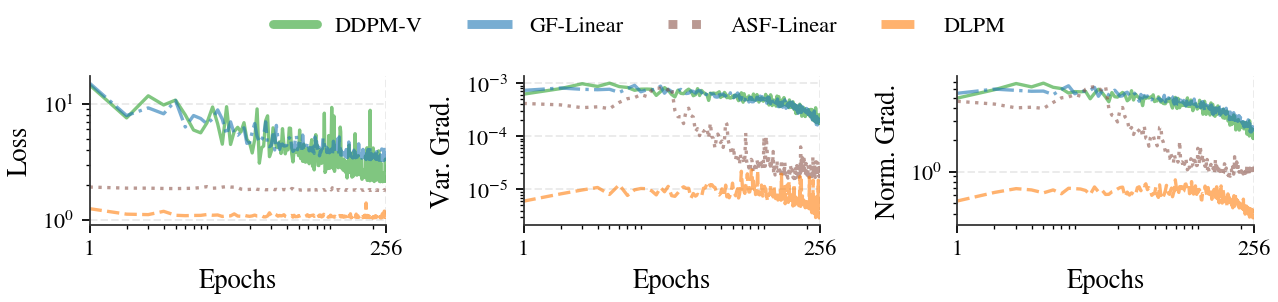

In [8]:


avg_loss_by_model = {spec["name"]: _average_run_curve(curve_runs[spec["name"]], "training_loss") for spec in model_specs}
avg_grad_var_by_model = {spec["name"]: _average_run_curve(curve_runs[spec["name"]], "grad_variance_epoch") for spec in model_specs}
avg_grad_norm_by_model = {spec["name"]: _average_run_curve(curve_runs[spec["name"]], "grad_norm_epoch") for spec in model_specs}
max_loss_epochs = max(curve.size for curve in avg_loss_by_model.values())
max_grad_var_epochs = max(curve.size for curve in avg_grad_var_by_model.values())
max_grad_norm_epochs = max(curve.size for curve in avg_grad_norm_by_model.values())

fig, axis = plt.subplots(1, 3, figsize=(8.25, 2.0), squeeze=False)

for spec in model_specs:
    color = source_colors[spec["name"]]
    avg_loss = avg_loss_by_model[spec["name"]]
    avg_grad_var = avg_grad_var_by_model[spec["name"]]
    avg_grad_norm = avg_grad_norm_by_model[spec["name"]]
    axis[0, 0].plot(np.arange(1, avg_loss.size + 1), avg_loss, color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)
    axis[0, 1].plot(np.arange(1, avg_grad_var.size + 1), avg_grad_var, color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)
    axis[0, 2].plot(np.arange(1, avg_grad_norm.size + 1), avg_grad_norm, color=color, linestyle=spec["linestyle"], lw=1.5, alpha=0.6)

axis[0, 0].set_xscale("log")
axis[0, 0].set_yscale("log")
axis[0, 0].set_xlim(1, max_loss_epochs)
axis[0, 0].set_xticks([1, max_loss_epochs], ["1", f"{max_loss_epochs}"])
axis[0, 0].set_xlabel("Epochs")
axis[0, 0].set_ylabel("Loss")

axis[0, 1].set_xscale("log")
axis[0, 1].set_yscale("log")
axis[0, 1].set_xlim(1, max_grad_var_epochs)
axis[0, 1].set_xticks([1, max_grad_var_epochs], ["1", f"{max_grad_var_epochs}"])
axis[0, 1].set_xlabel("Epochs")
axis[0, 1].set_ylabel("Var. Grad.")

axis[0, 2].set_xscale("log")
axis[0, 2].set_yscale("log")
axis[0, 2].set_xlim(1, max_grad_norm_epochs)
axis[0, 2].set_xticks([1, max_grad_norm_epochs], ["1", f"{max_grad_norm_epochs}"])
axis[0, 2].set_xlabel("Epochs")
axis[0, 2].set_ylabel("Norm. Grad.")

legend_handles = [Line2D([0], [0], color=source_colors[spec["name"]], lw=4.0, linestyle=spec["linestyle"], label=spec["name"], alpha=0.6)
                  for spec in model_specs]
fig.legend(legend_handles, [handle.get_label() for handle in legend_handles],
           loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=len(model_specs), frameon=False, fontsize=10)
fig.tight_layout(rect=(0, 0, 1.0, 0.86))


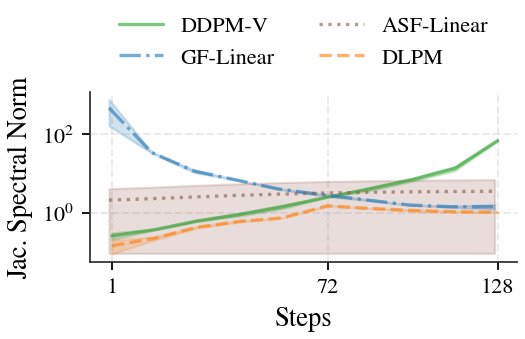

In [9]:
fig, axis = plt.subplots(1, 1, figsize=(3.6, 2.4), squeeze=False)

for spec in model_specs:
    curves = jacobian_runs[spec["name"]]
    if not curves:
        continue
    min_len = min(len(curve) for _, curve in curves)
    t_grid = curves[0][0][:min_len]
    values = np.stack([curve[:min_len] for _, curve in curves], axis=0)
    avg_curve = values.mean(axis=0)
    std_curve = values.std(axis=0)
    axis[0, 0].plot(t_grid, avg_curve, color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=1.5, alpha=0.6, label=spec["name"])
    axis[0, 0].fill_between(t_grid, avg_curve - std_curve, avg_curve + std_curve, color=source_colors[spec["name"]], alpha=0.2)

axis[0, 0].set_yscale("log")
xticks = [t_grid[0], t_grid[len(t_grid) // 2], t_grid[-1]]
axis[0, 0].set_xticks(xticks, [f"{int(tick)}" for tick in xticks])
axis[0, 0].set_xlabel("Steps")
axis[0, 0].set_ylabel("Jac. Spectral Norm")
axis[0, 0].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=10)

fig.tight_layout()
plt.show()


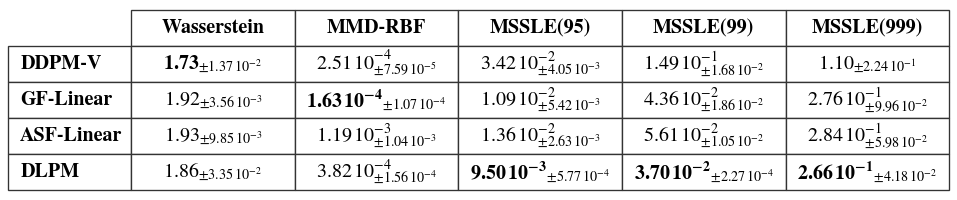

In [10]:
fig, axis = plt.subplots(1, 1, figsize=(6.6, 1.5), squeeze=False)
axis[0, 0].axis("off")
table = axis[0, 0].table(
    cellText=formatted.values,
    rowLabels=formatted.index,
    colLabels=["Wasserstein", "MMD-RBF", "MSSLE(95)", "MSSLE(99)", "MSSLE(999)"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("0.2")
    cell.set_linewidth(0.6)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

plt.show()


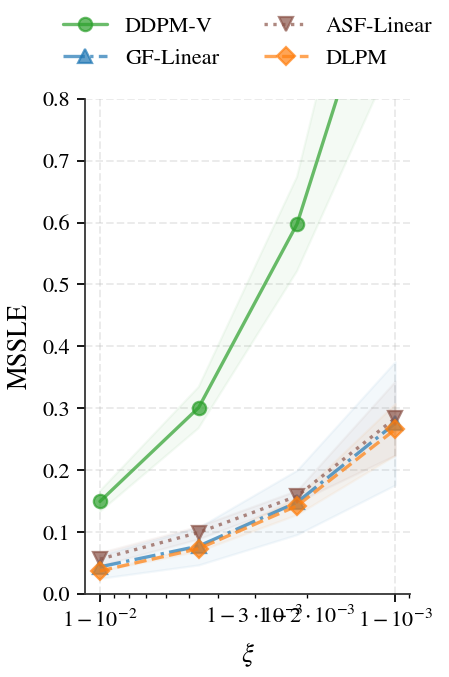

In [11]:
start = 3  # Skip the first two points which are too close to 0
fig, axes = plt.subplots(1, 1, figsize=(3, 4.5), sharex=True, squeeze=False)

for spec in model_specs:
    model_curves = [curve for curve in tail_curves if curve["model"] == spec["name"]]
    if not model_curves:
        continue
    avg_curve = np.mean(np.stack([curve['mssle'] for curve in model_curves], axis=0), axis=0)[start:]
    std_curve = np.std(np.stack([curve['mssle'] for curve in model_curves], axis=0), axis=0)[start:]
    axes[0, 0].plot(xis[start:], avg_curve, lw=1.5, color=source_colors[spec["name"]], linestyle=spec["linestyle"], marker=spec["marker"], label=spec["name"], alpha=0.7)
    axes[0, 0].fill_between(xis[start:], avg_curve - std_curve, avg_curve + std_curve, color=source_colors[spec["name"]], alpha=0.05)

axes[0, 0].set_ylim(bottom=0, top=0.8)
axes[0, 0].set_xscale("logit")
axes[0, 0].set_xlabel(r"$\xi$")
axes[0, 0].set_ylabel("MSSLE")

axes[0, 0].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=10)

fig.tight_layout()
plt.show()
